<a href="https://colab.research.google.com/github/ai7dnn/2026-1-BDA/blob/main/code/10w_data_vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 93.6 MB/s eta 0:00:00


In [3]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 85.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=9c0d518d2ef0ccd38644ed4c99670a5b7dca9db3fa79ee7cf3a0178202997e28
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
from pydataset import data
iris = data('iris')
iris.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 1 to 150
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 7.0+ KB


In [5]:
iris.describe()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
iris.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [7]:
iris.Species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [8]:
iris.Species.value_counts()

,count
Species,
setosa,50
versicolor,50
virginica,50


In [9]:
from IPython.display import display_html
def display_side_by_side(*args):
    """여러 데이터프레임 비교가 쉽게 옆쪽으로 표시한다"""
    html_str=''
    for df in args:
        html_str += df.to_html() + '&nbsp;'*4
    display_html(html_str.replace('table','table style="display:inline"'), raw=True)

In [10]:
from IPython.display import display_html

def display_series_side_by_side(*args, names=None):
    """여러 Series를 옆으로 나란히 표시한다.

    Parameters
    ----------
    *args   : pd.Series 객체들
    names   : 각 Series의 제목 리스트 (생략 시 Series.name 사용)
    """
    html_str = ''
    for i, s in enumerate(args):
        # 제목 결정: names 인자 > Series.name > 인덱스 번호
        if names and i < len(names):
            title = names[i]
        elif s.name is not None:
            title = s.name
        else:
            title = f'Series {i}'

        table_html = s.to_frame(name=title).to_html()
        html_str += table_html + '&nbsp;' * 4

    display_html(
        html_str.replace('table', 'table style="display:inline; vertical-align:top"'),
        raw=True
    )

In [11]:
display_side_by_side(iris.head(), iris.tail())

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
146,6.7,3.0,5.2,2.3,virginica
147,6.3,2.5,5.0,1.9,virginica
148,6.5,3.0,5.2,2.0,virginica
149,6.2,3.4,5.4,2.3,virginica


In [14]:
display_series_side_by_side(iris['Petal.Length'][:5], iris.Species.value_counts())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [16]:
display_side_by_side(iris['Petal.Length'][:5].to_frame(), iris.Species.value_counts().to_frame())

,Petal.Length
1,1.4
2,1.4
3,1.3
4,1.5
5,1.4
,count
Species,
setosa,50
versicolor,50
virginica,50


In [27]:
plt.rcParams['figure.figsize'] = (5, 3)

[ 4.  5.  7. 16.  9.  5. 13. 14. 10.  6. 10. 16.  7. 11.  4.  2.  4.  1.
  5.  1.]
[4.3  4.48 4.66 4.84 5.02 5.2  5.38 5.56 5.74 5.92 6.1  6.28 6.46 6.64
 6.82 7.   7.18 7.36 7.54 7.72 7.9 ]
<BarContainer object of 20 artists>


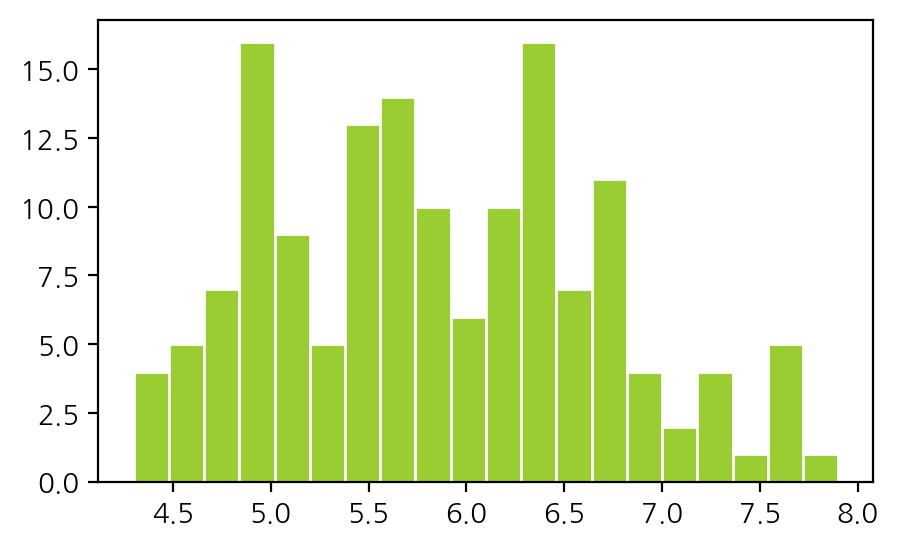

In [28]:
import matplotlib.pyplot as plt

n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20,
                            color='yellowgreen', edgecolor='white')
print(n)
print(bins)
print(patches)

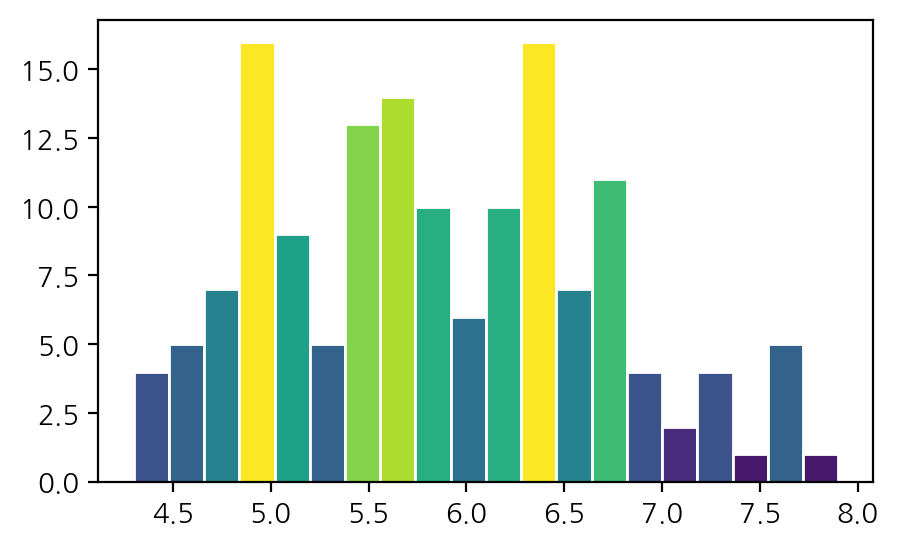

In [29]:
n, bins, patches = plt.hist(iris['Sepal.Length'], bins = 20,
                            color='yellowgreen', edgecolor='white')
for i in range(len(patches)):
    patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))
plt.show()

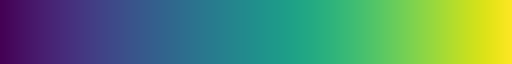

In [30]:
plt.cm.viridis

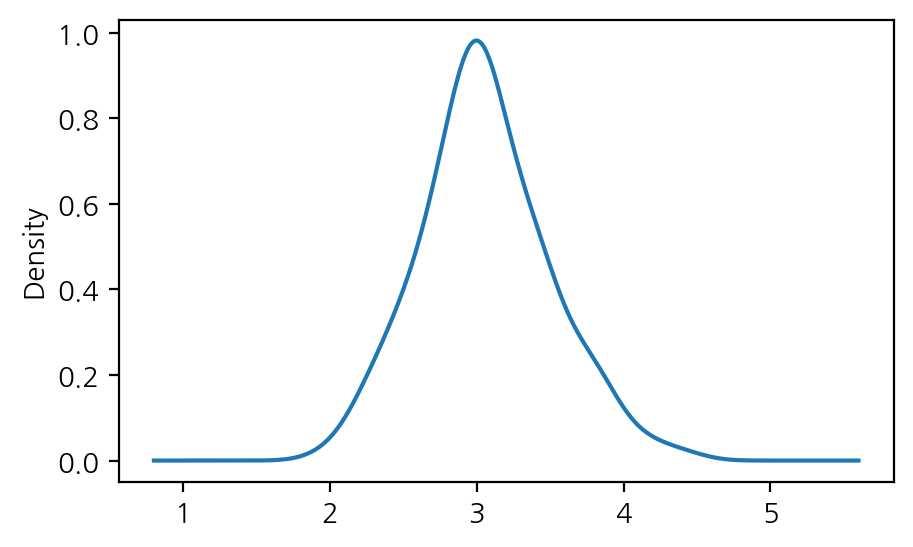

In [31]:
iris['Sepal.Width'].plot.density();

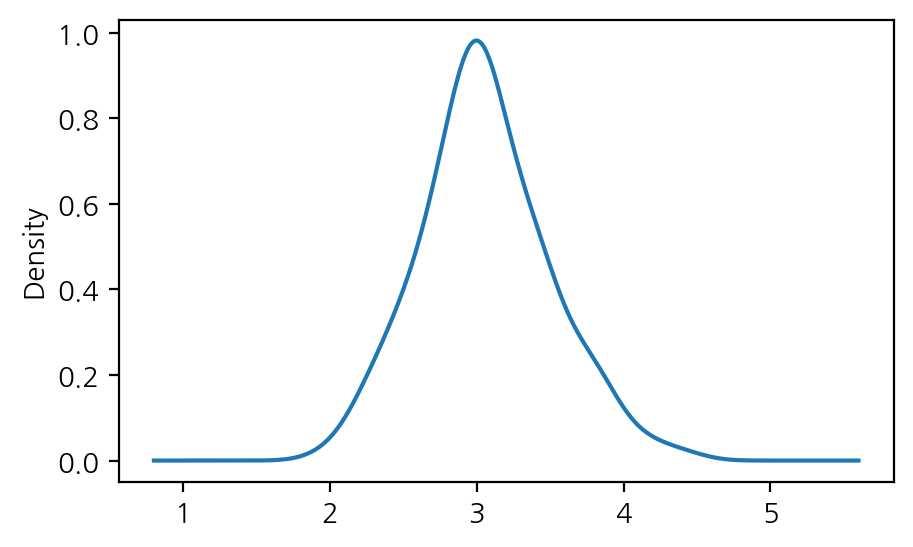

In [32]:
iris['Sepal.Width'].plot.kde();

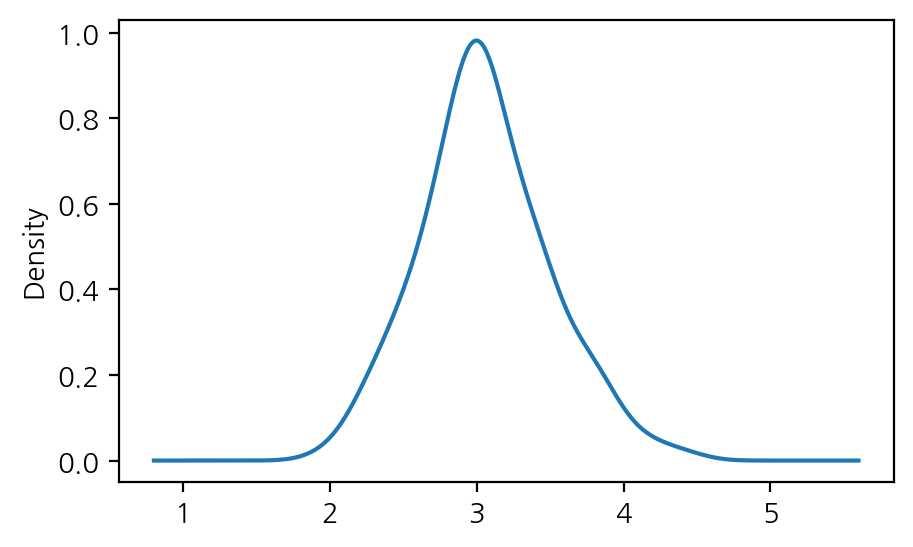

In [33]:
iris['Sepal.Width'].plot.density();

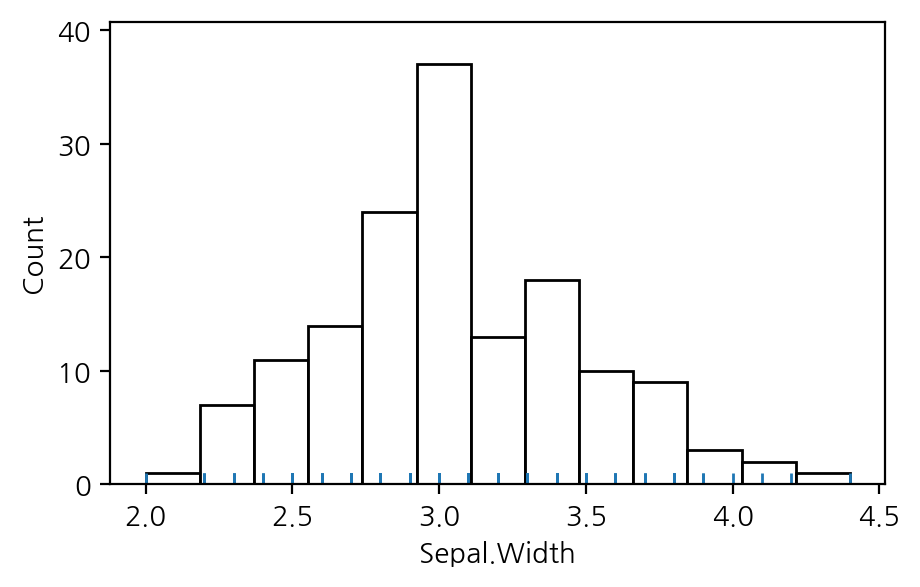

In [34]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width']);

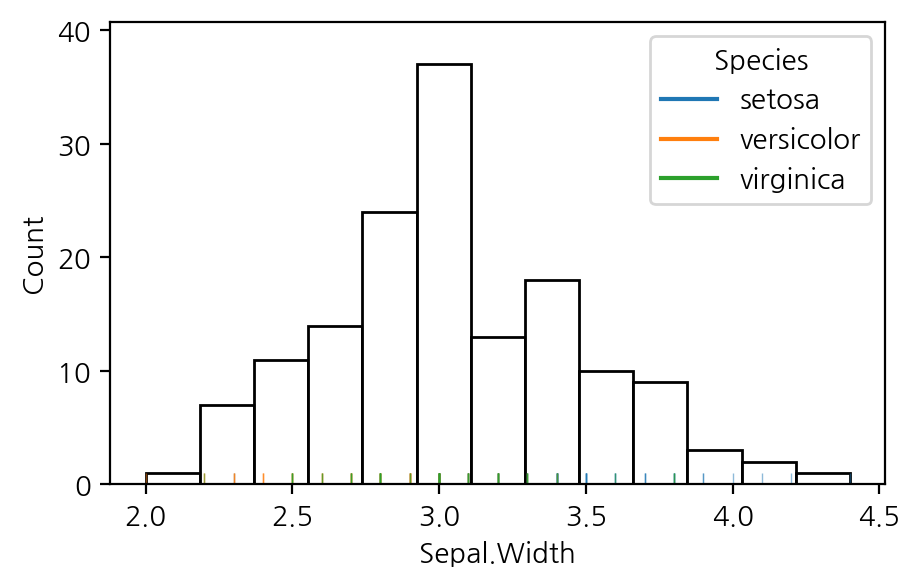

In [36]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'], linewidth=0.5, hue='Species', alpha=.5);

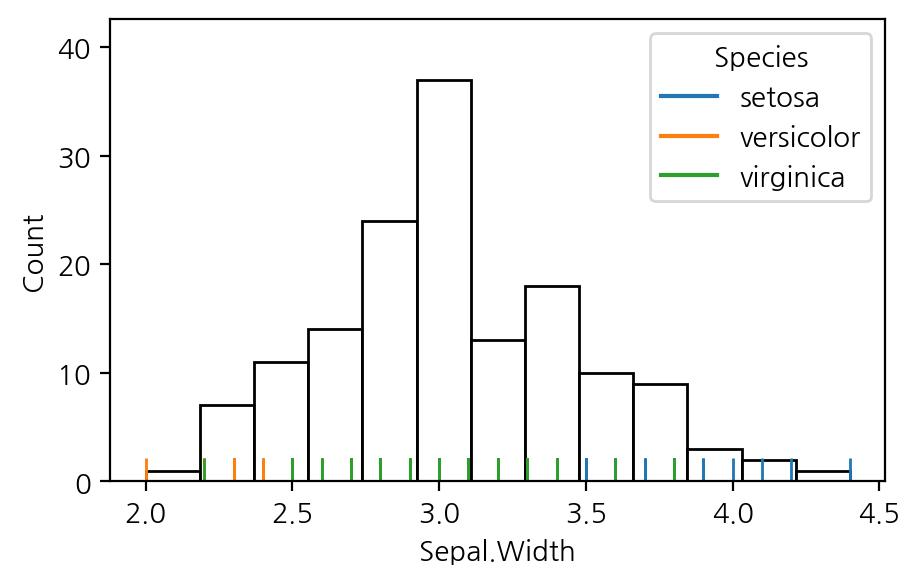

In [37]:
import seaborn as sns
sns.histplot(data = iris, x = iris['Sepal.Width'], color='white')
sns.rugplot(data = iris, x = iris['Sepal.Width'], height=0.05, hue='Species');

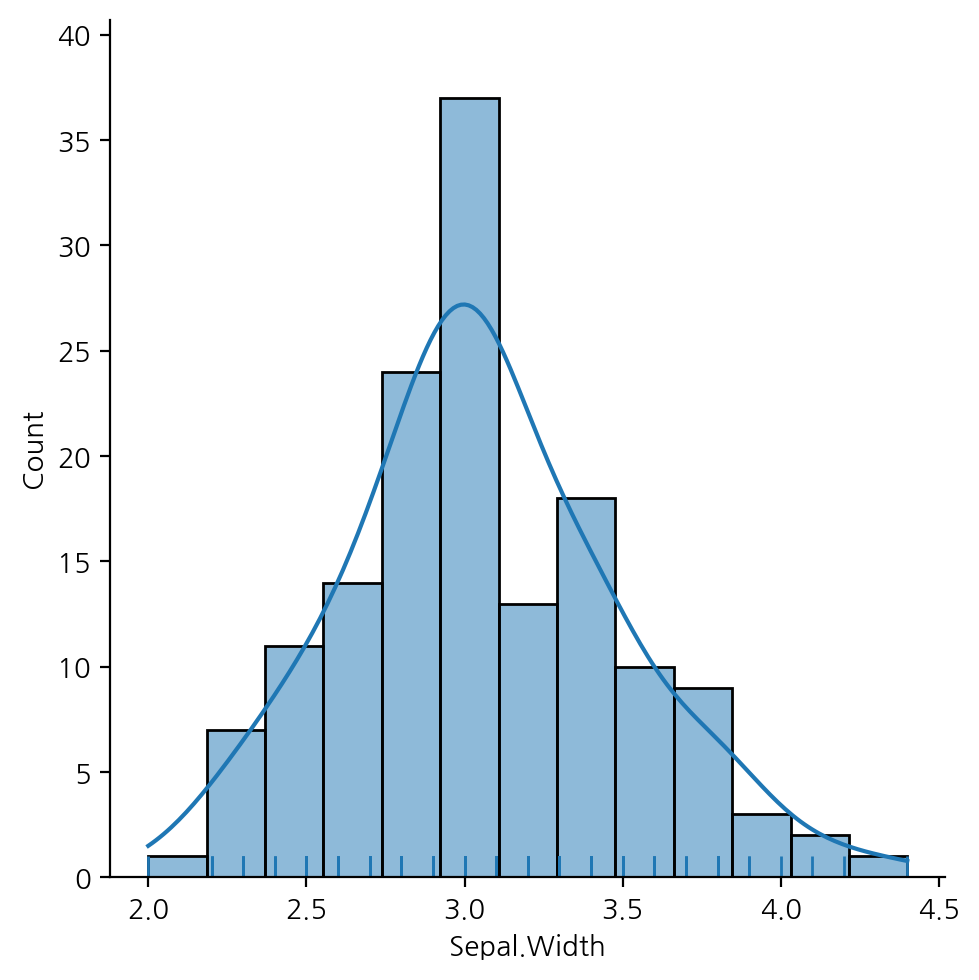

In [38]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True);

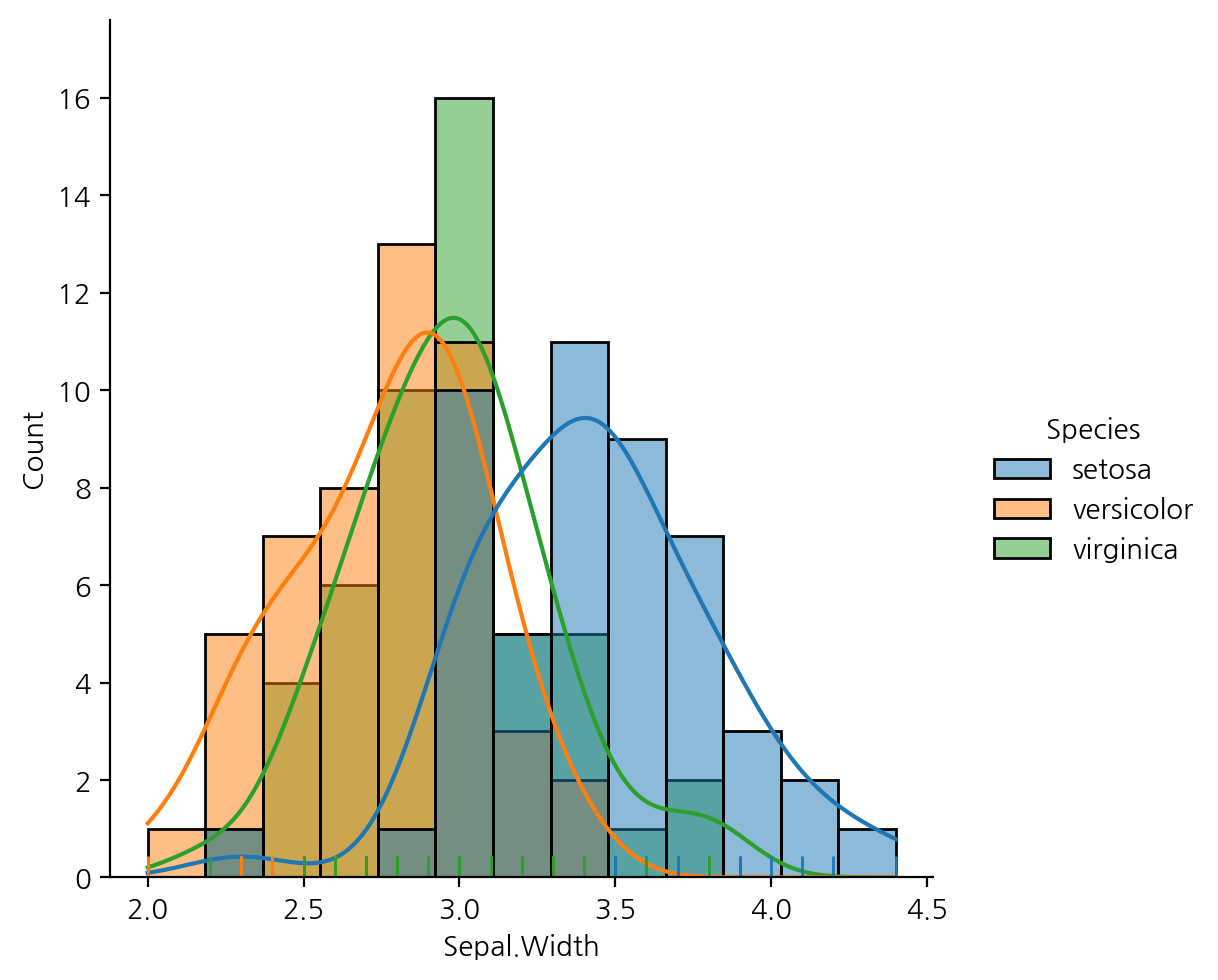

In [39]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True, hue='Species');

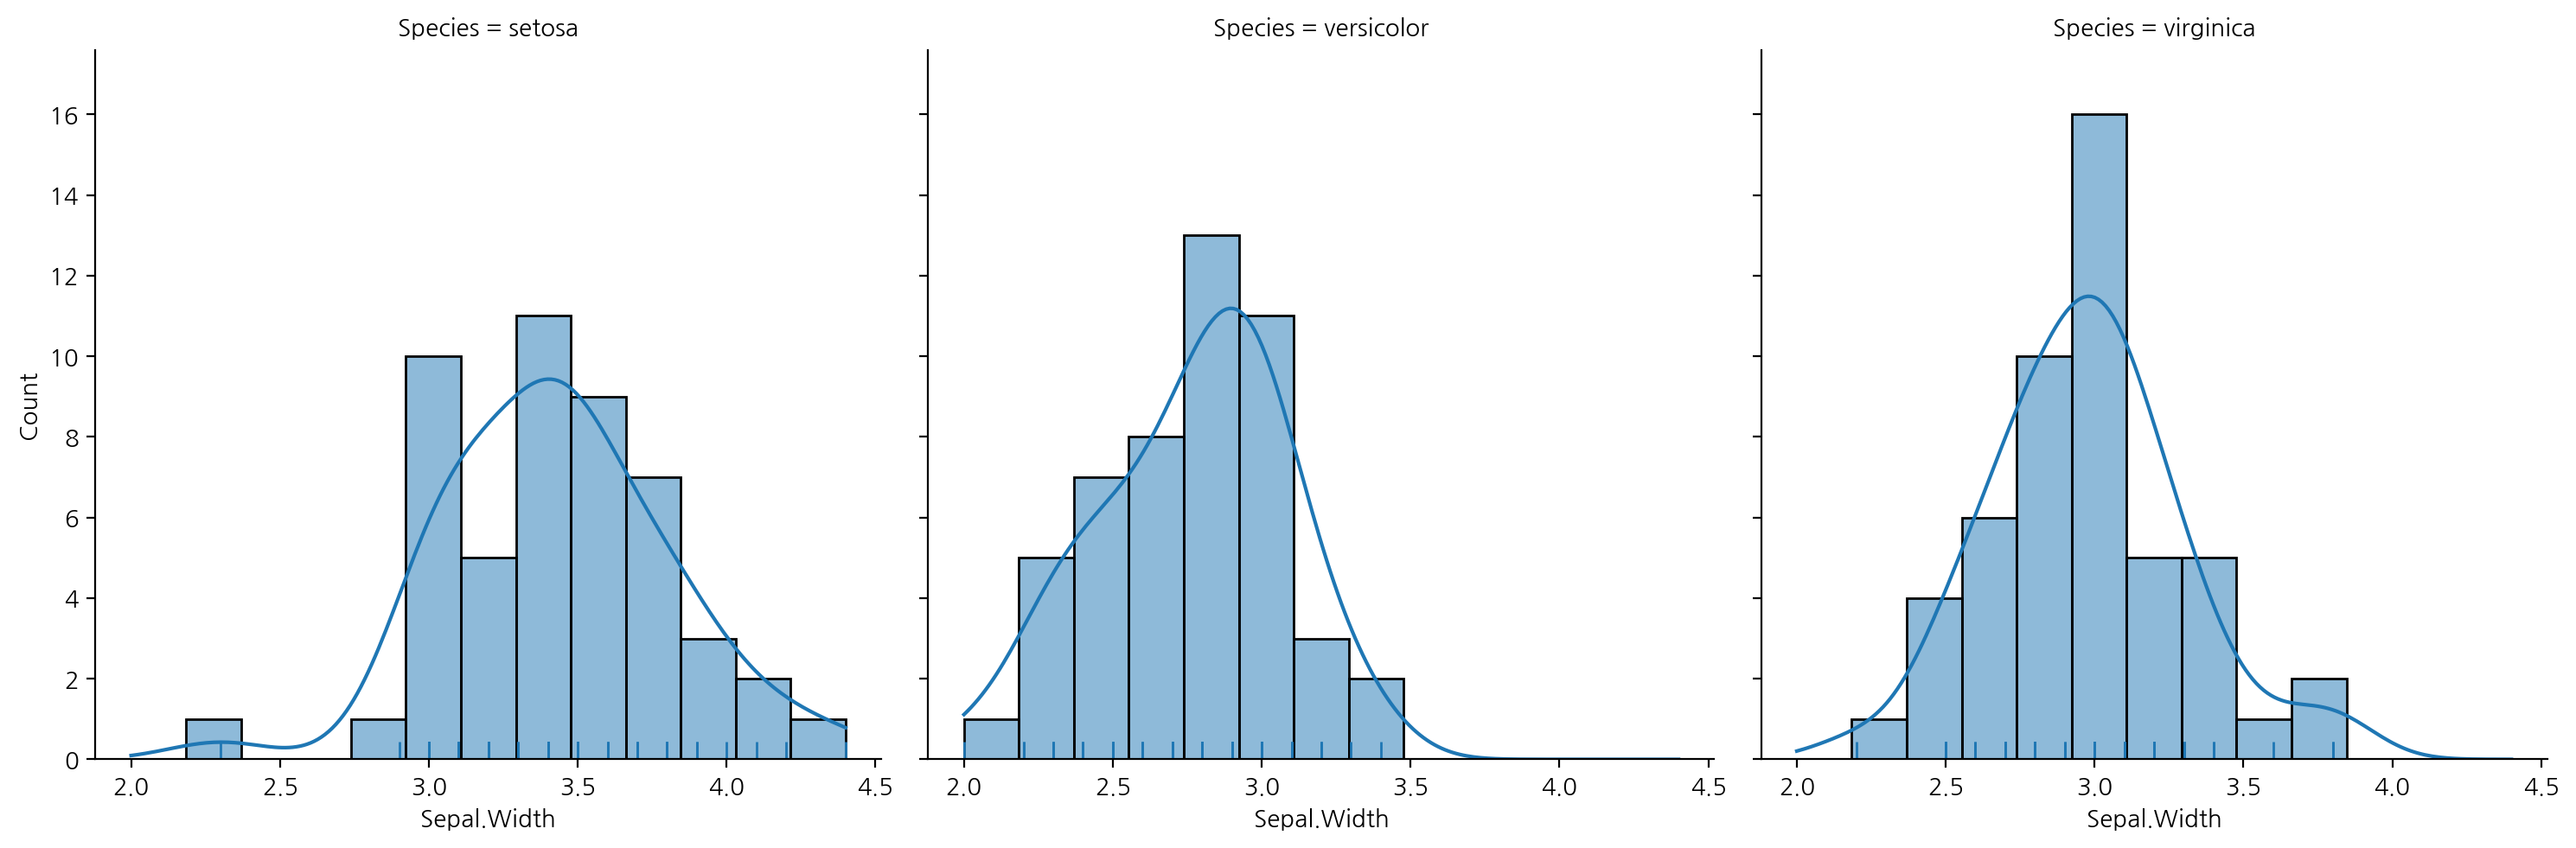

In [40]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], col="Species", kde=True, rug=True);

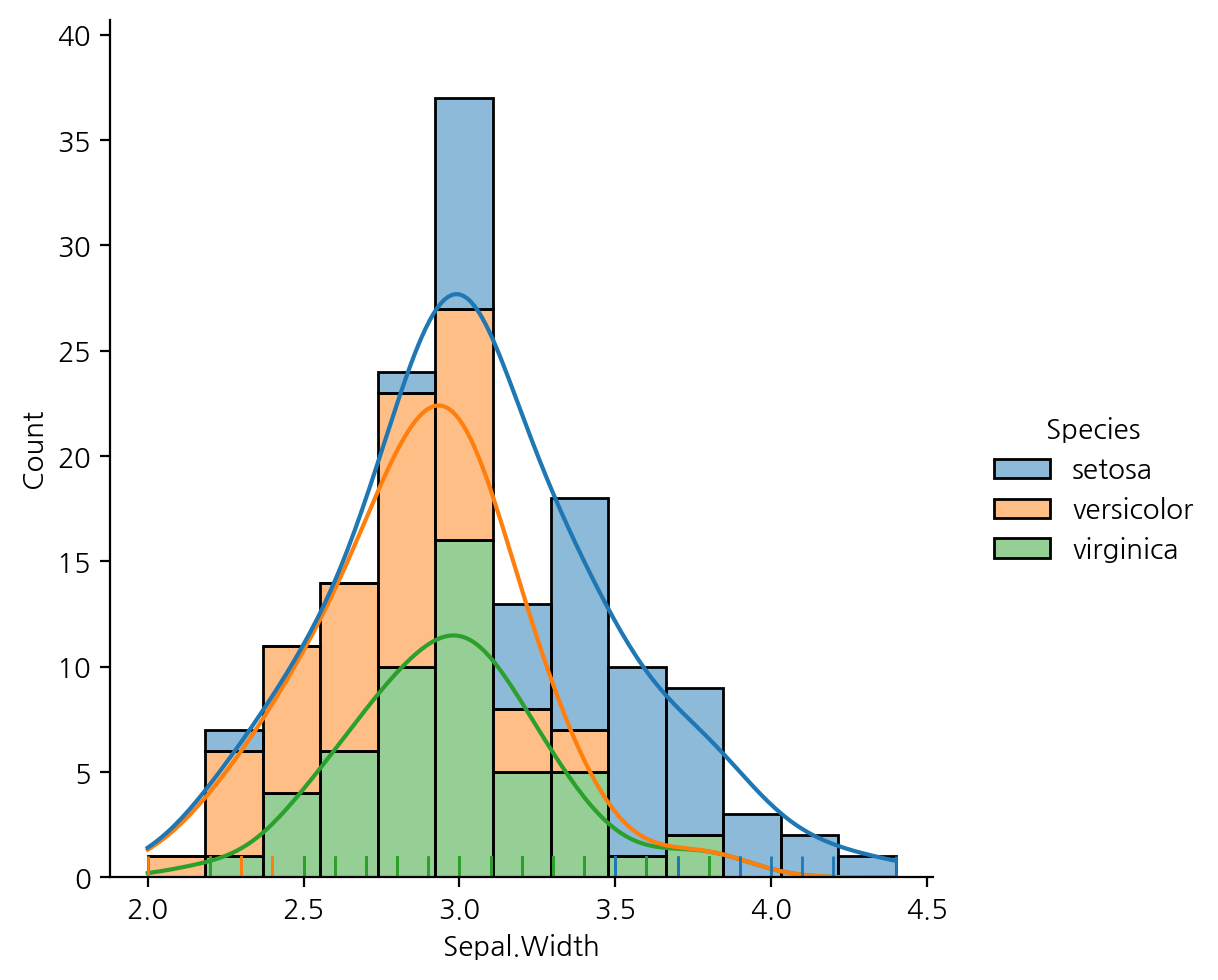

In [41]:
import seaborn as sns
sns.displot(data = iris, x = iris['Sepal.Width'], kde=True, rug=True, multiple="stack", hue="Species");

In [42]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [43]:
pd.set_option('display.precision', 2)

In [45]:
iris.columns[:-1].tolist()

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [44]:
corr = iris[iris.columns[:-1].tolist()].corr()
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


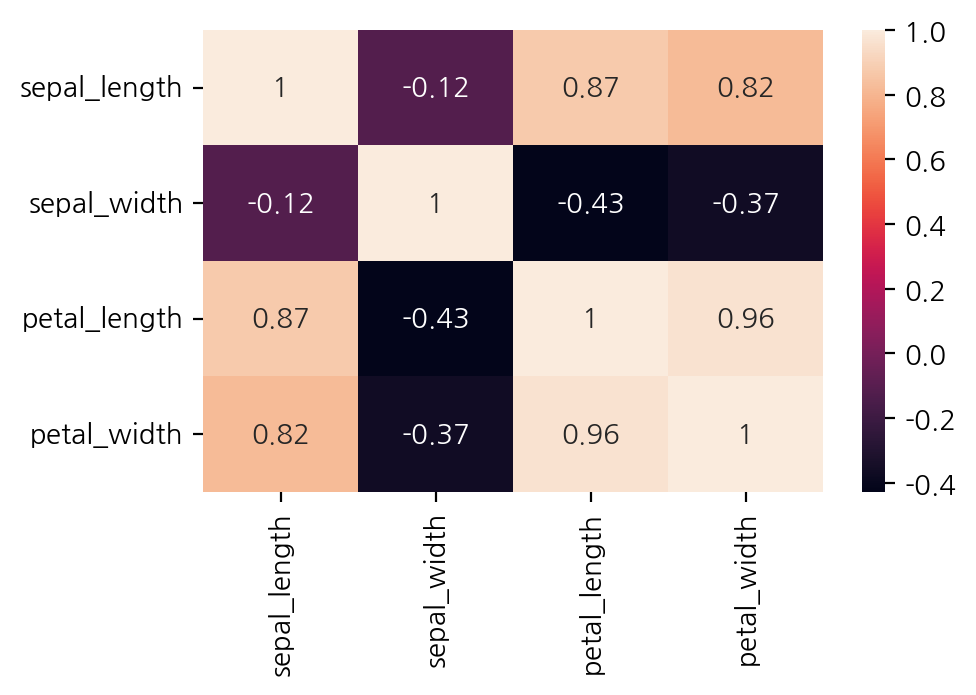

In [46]:
sns.heatmap(corr, annot=True);

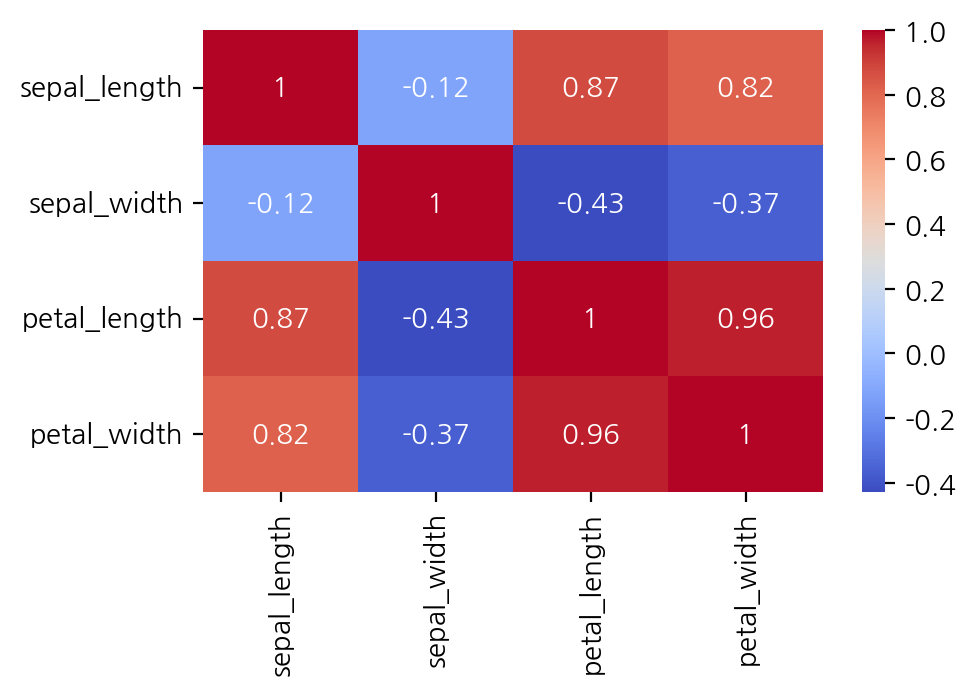

In [54]:
sns.heatmap(corr, cmap='coolwarm', annot=True);

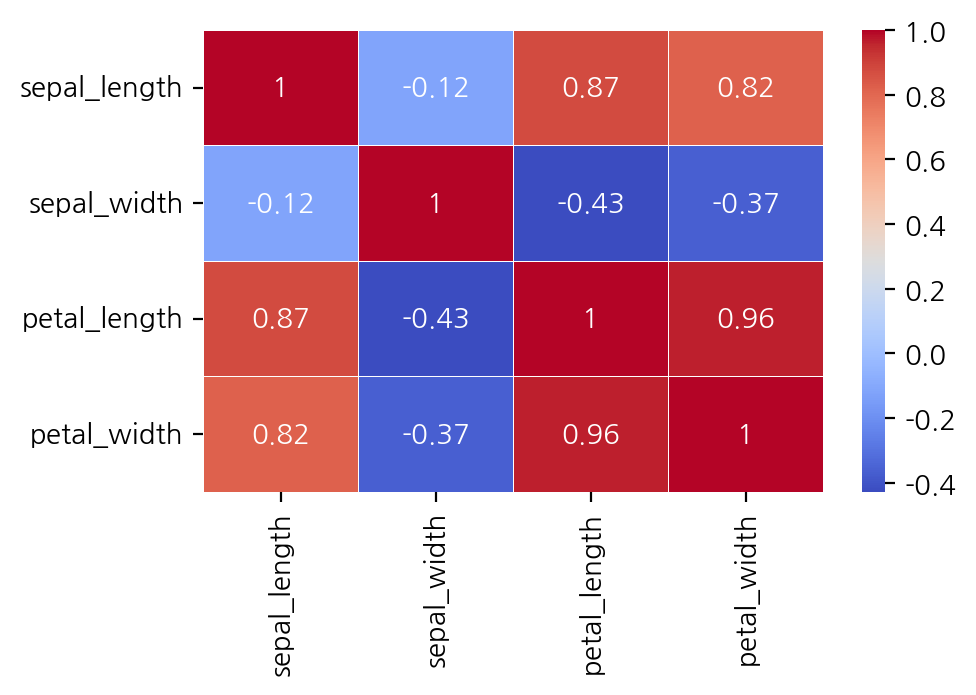

In [49]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=.2);

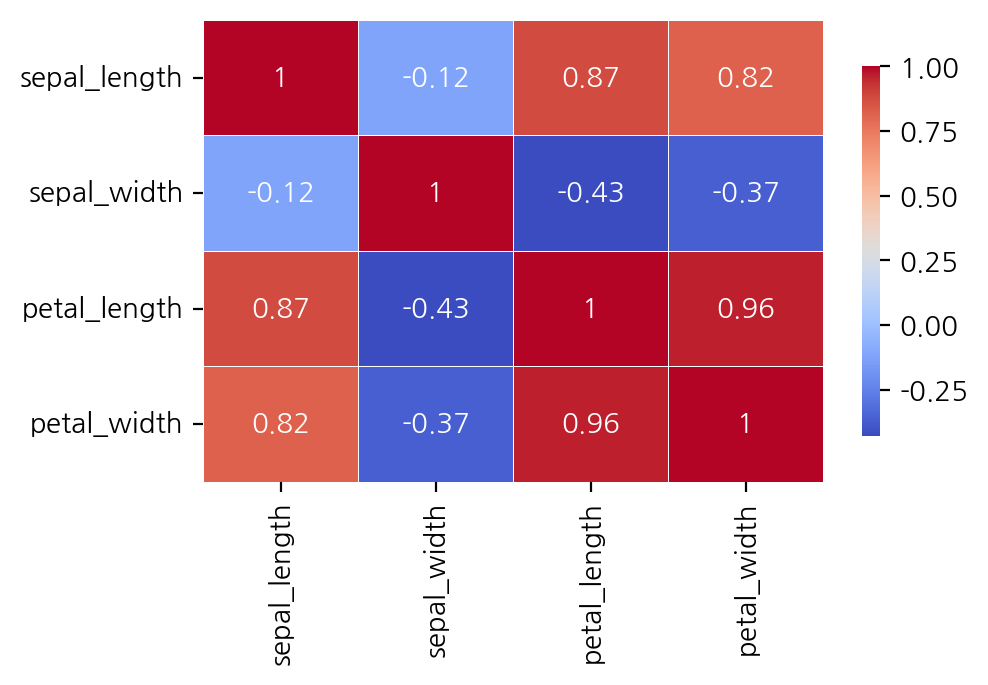

In [52]:
sns.heatmap(corr, cmap='coolwarm', annot=True, lw=.2, cbar_kws={'shrink': .8});

In [56]:
mask = np.zeros_like(corr)
mask

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [57]:
np.triu_indices_from(mask)

(array([0, 0, 0, 0, 1, 1, 1, 2, 2, 3]), array([0, 1, 2, 3, 1, 2, 3, 2, 3, 3]))

In [58]:
mask[np.triu_indices_from(mask)] = True
mask

array([[1., 1., 1., 1.],
       [0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.]])

In [59]:
mask_new = mask[1:, :-1]
mask_new

array([[0., 1., 1.],
       [0., 0., 1.],
       [0., 0., 0.]])

In [60]:
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.00,-0.12,0.87,0.82
sepal_width,-0.12,1.00,-0.43,-0.37
petal_length,0.87,-0.43,1.00,0.96
petal_width,0.82,-0.37,0.96,1.00


In [61]:
# 상관관계 계수 dataframe 첫 번째 행, 마지막 열 제거
corr_iris_new = corr.iloc[1:, :-1]
corr_iris_new

,sepal_length,sepal_width,petal_length
sepal_width,-0.12,1.00,-0.43
petal_length,0.87,-0.43,1.00
petal_width,0.82,-0.37,0.96


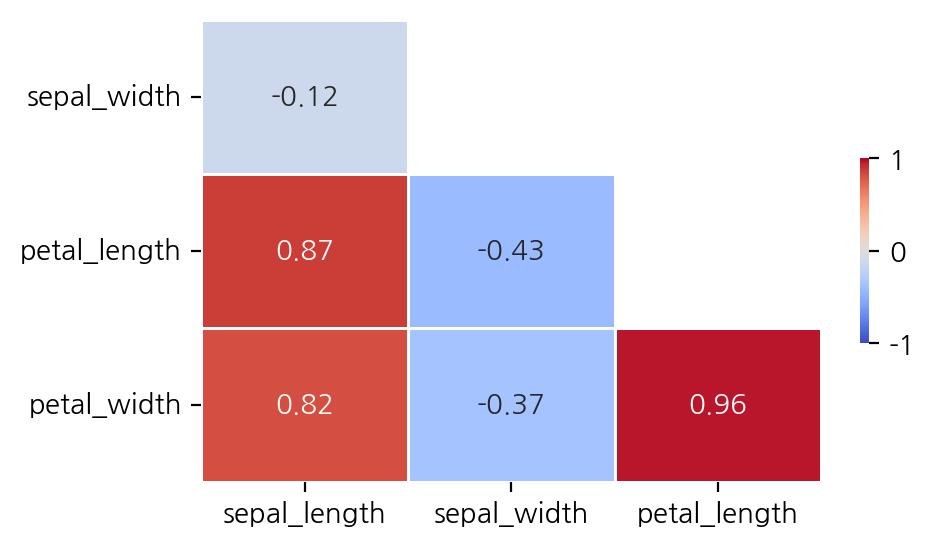

In [62]:
sns.heatmap(corr_iris_new, annot=True, cmap='coolwarm', mask=mask_new,
            annot_kws = {"size": 10}, vmin=-1, vmax=1,
            cbar_kws = {'shrink': .4},  # 범례 크기 줄이기
            linewidths = .5);           # 경계 구분선 추가

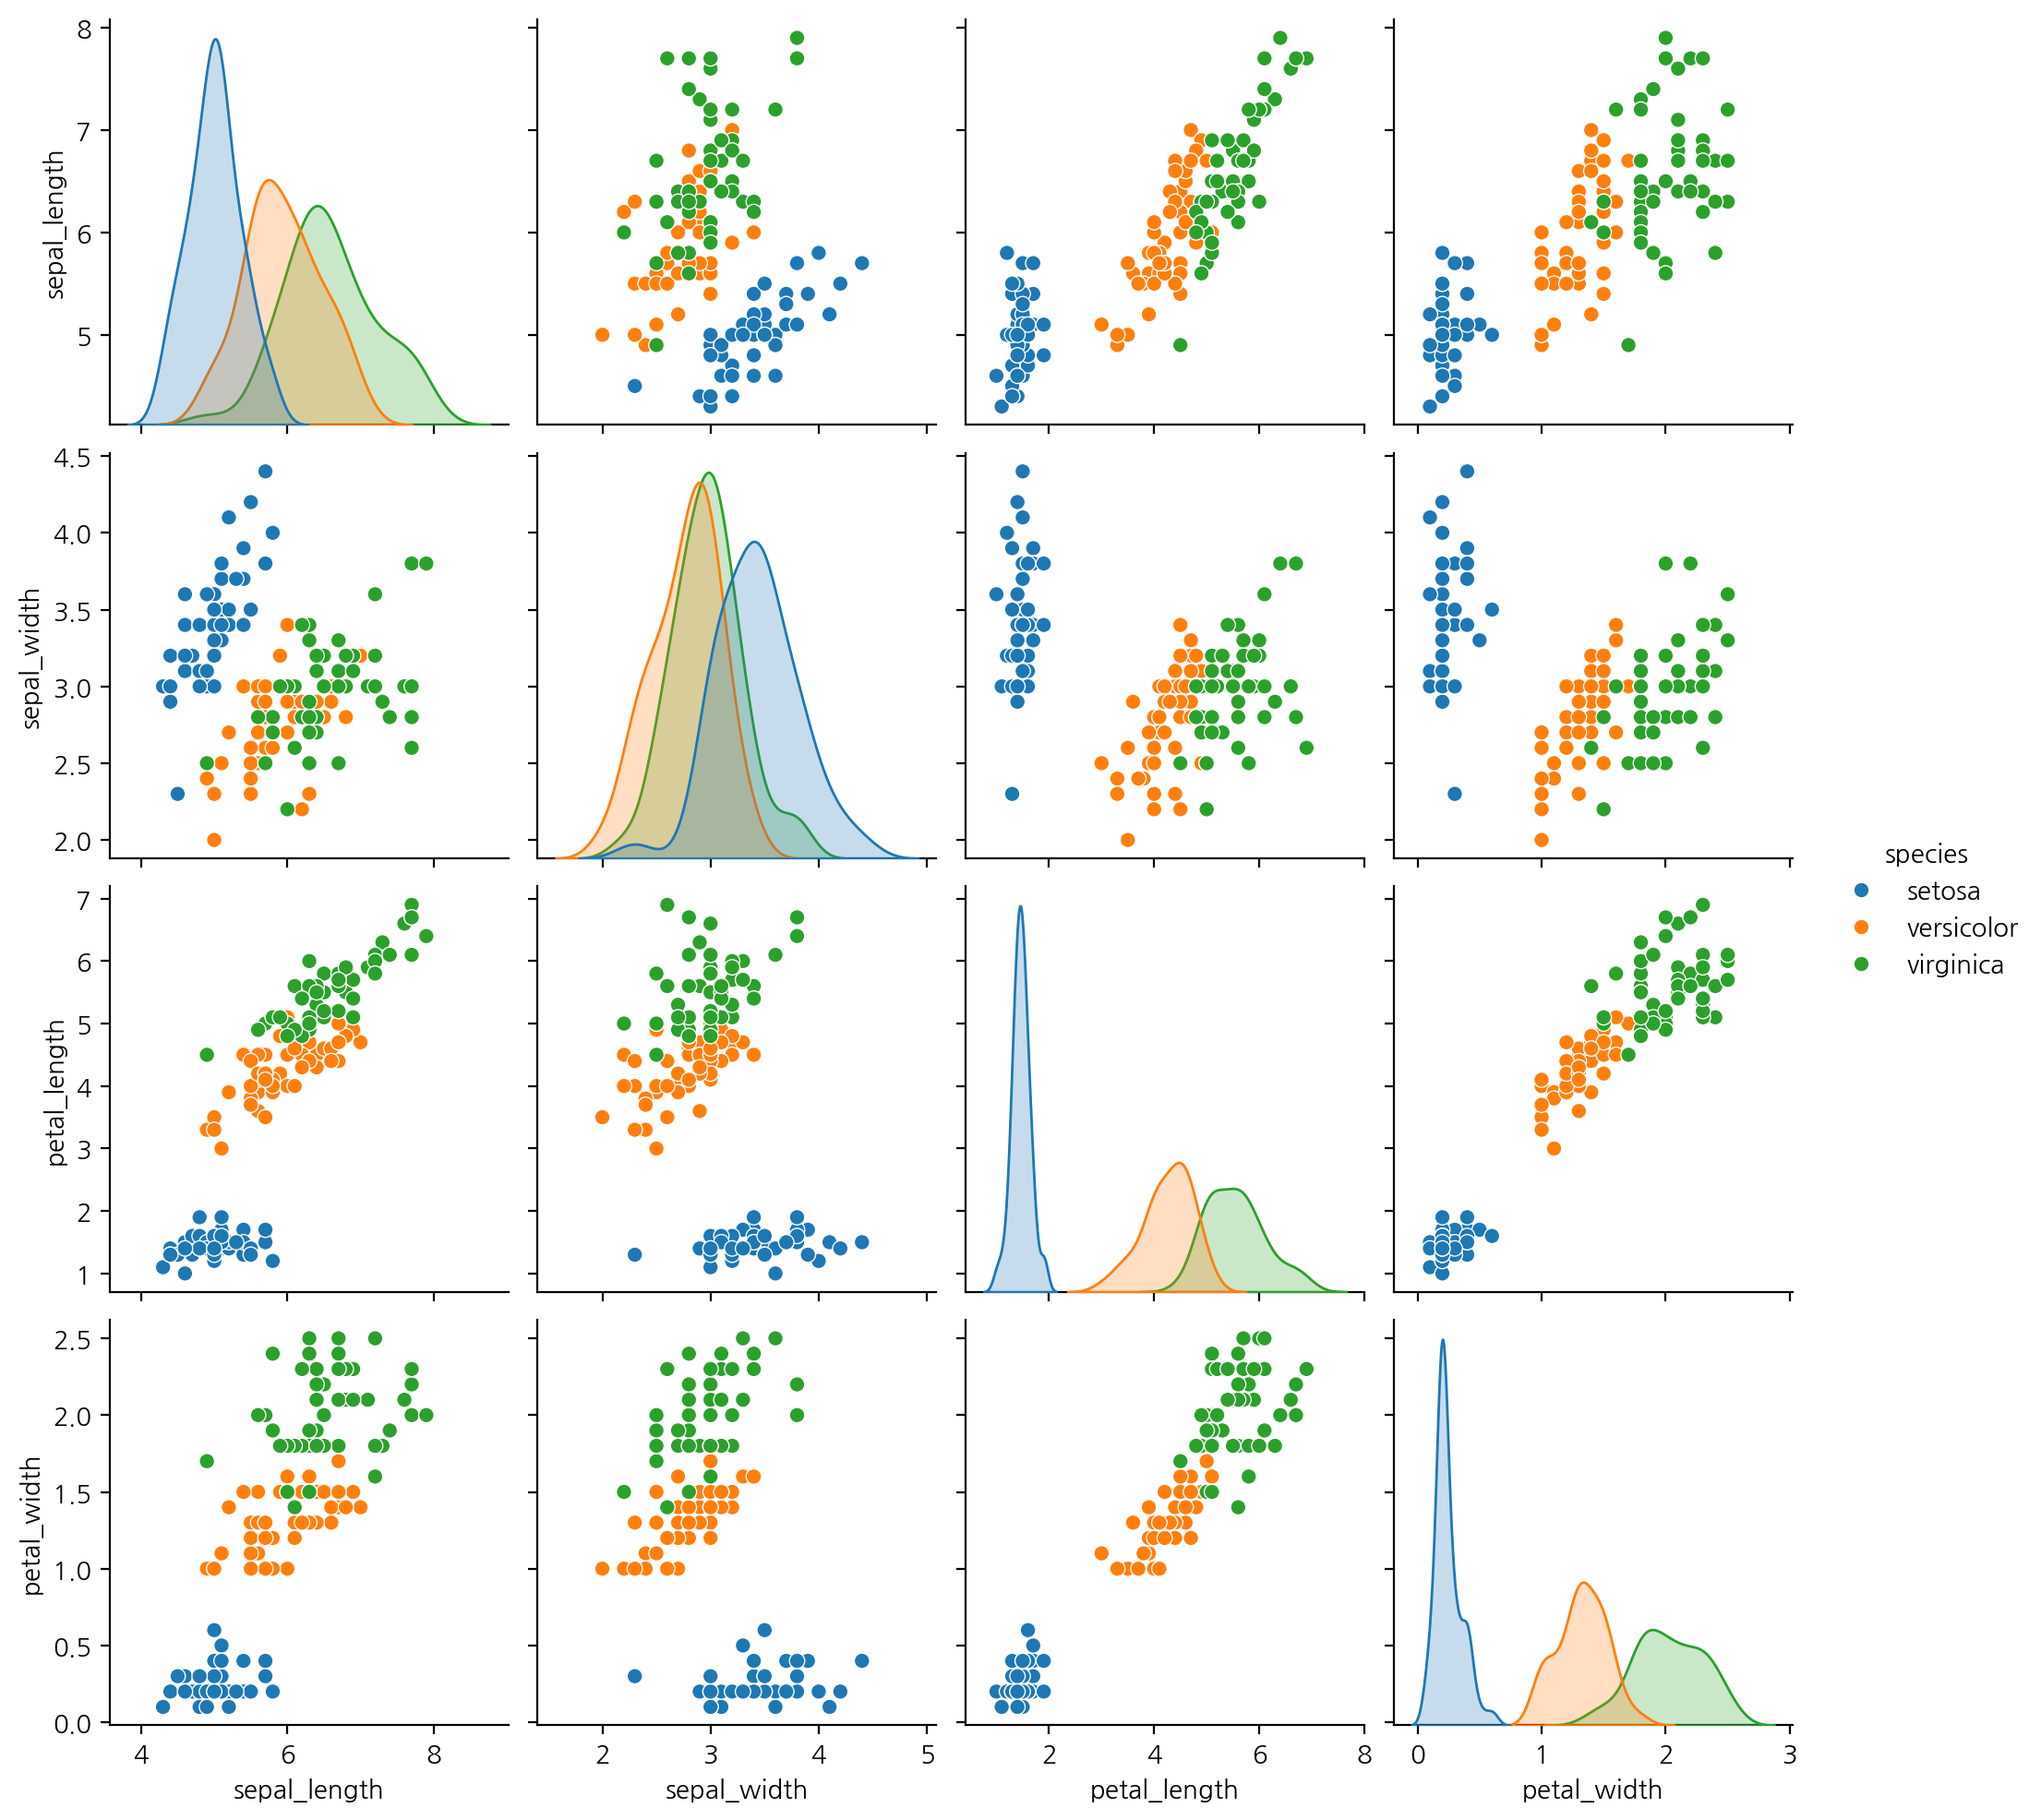

In [63]:
sns.pairplot(iris, hue='species');

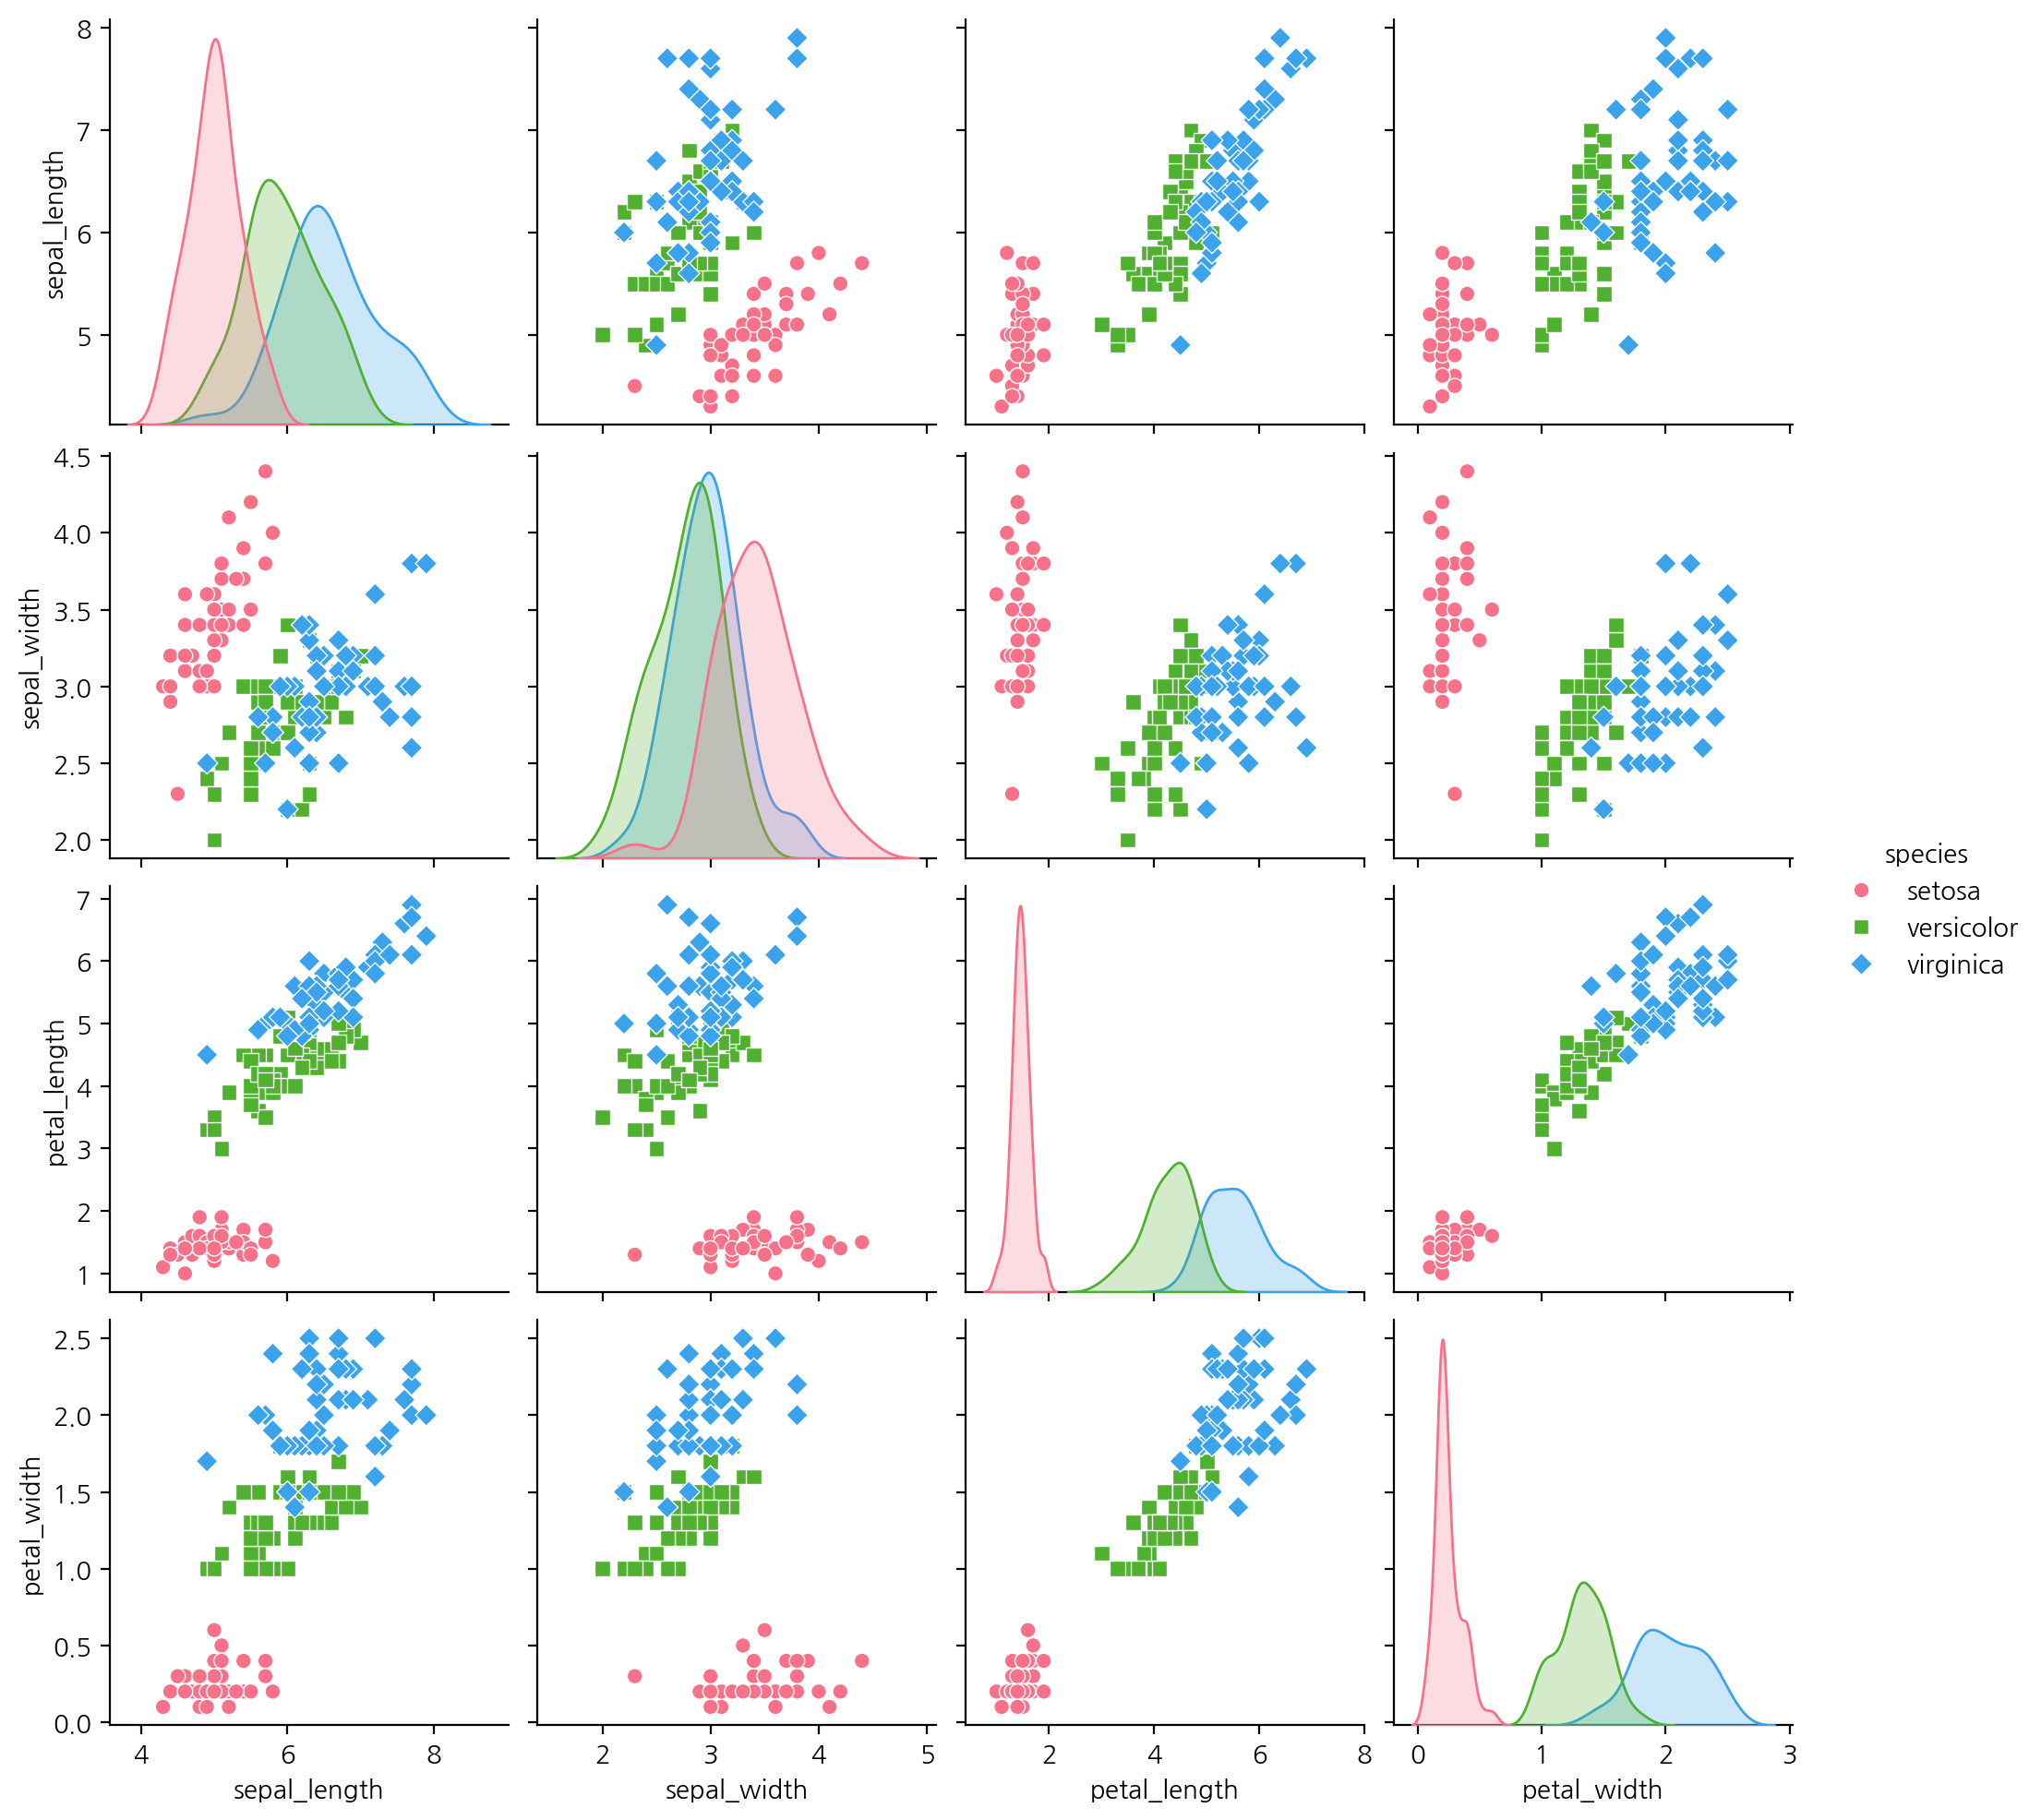

In [66]:
sns.pairplot(iris, hue="species", palette="husl", markers=["o", "s", "D"]);

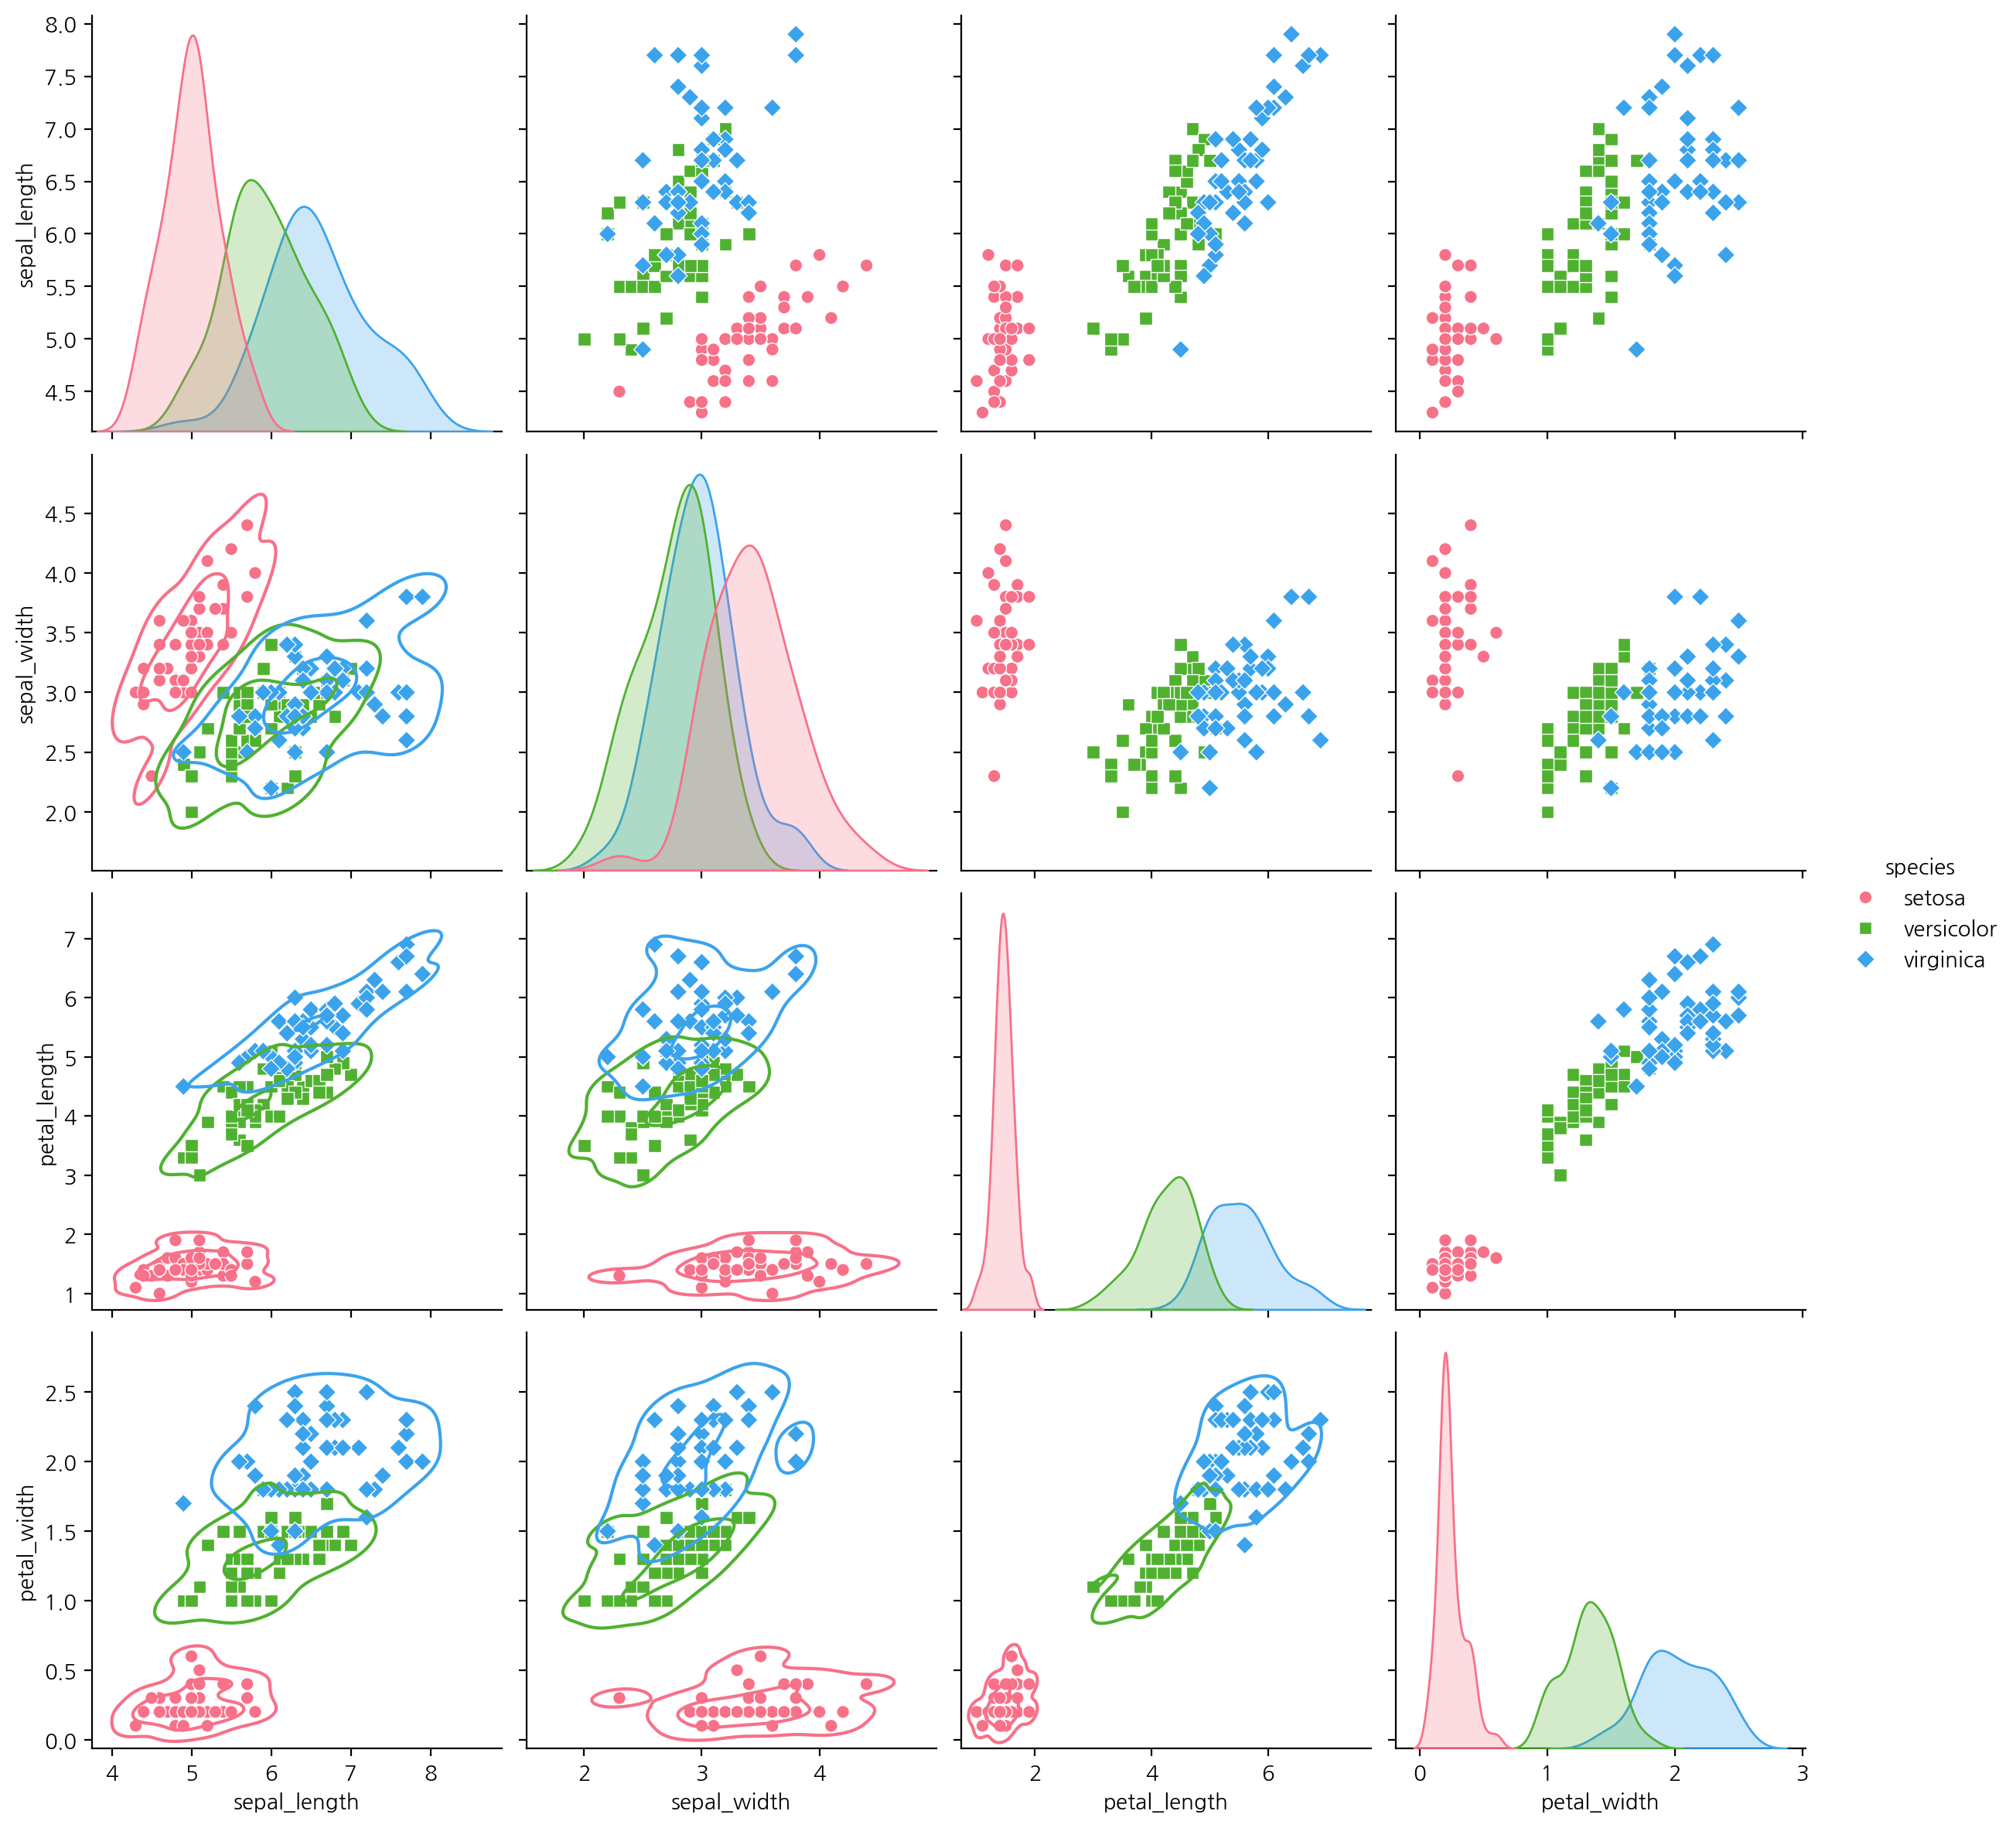

In [75]:
g = sns.pairplot(iris, hue="species", palette="husl", height=3, markers=["o", "s", "D"]);
g.map_lower(sns.kdeplot, levels=3); # 동고선의 색상, 0==검정, 1==흰색, hue 색상으로 구분 여려움

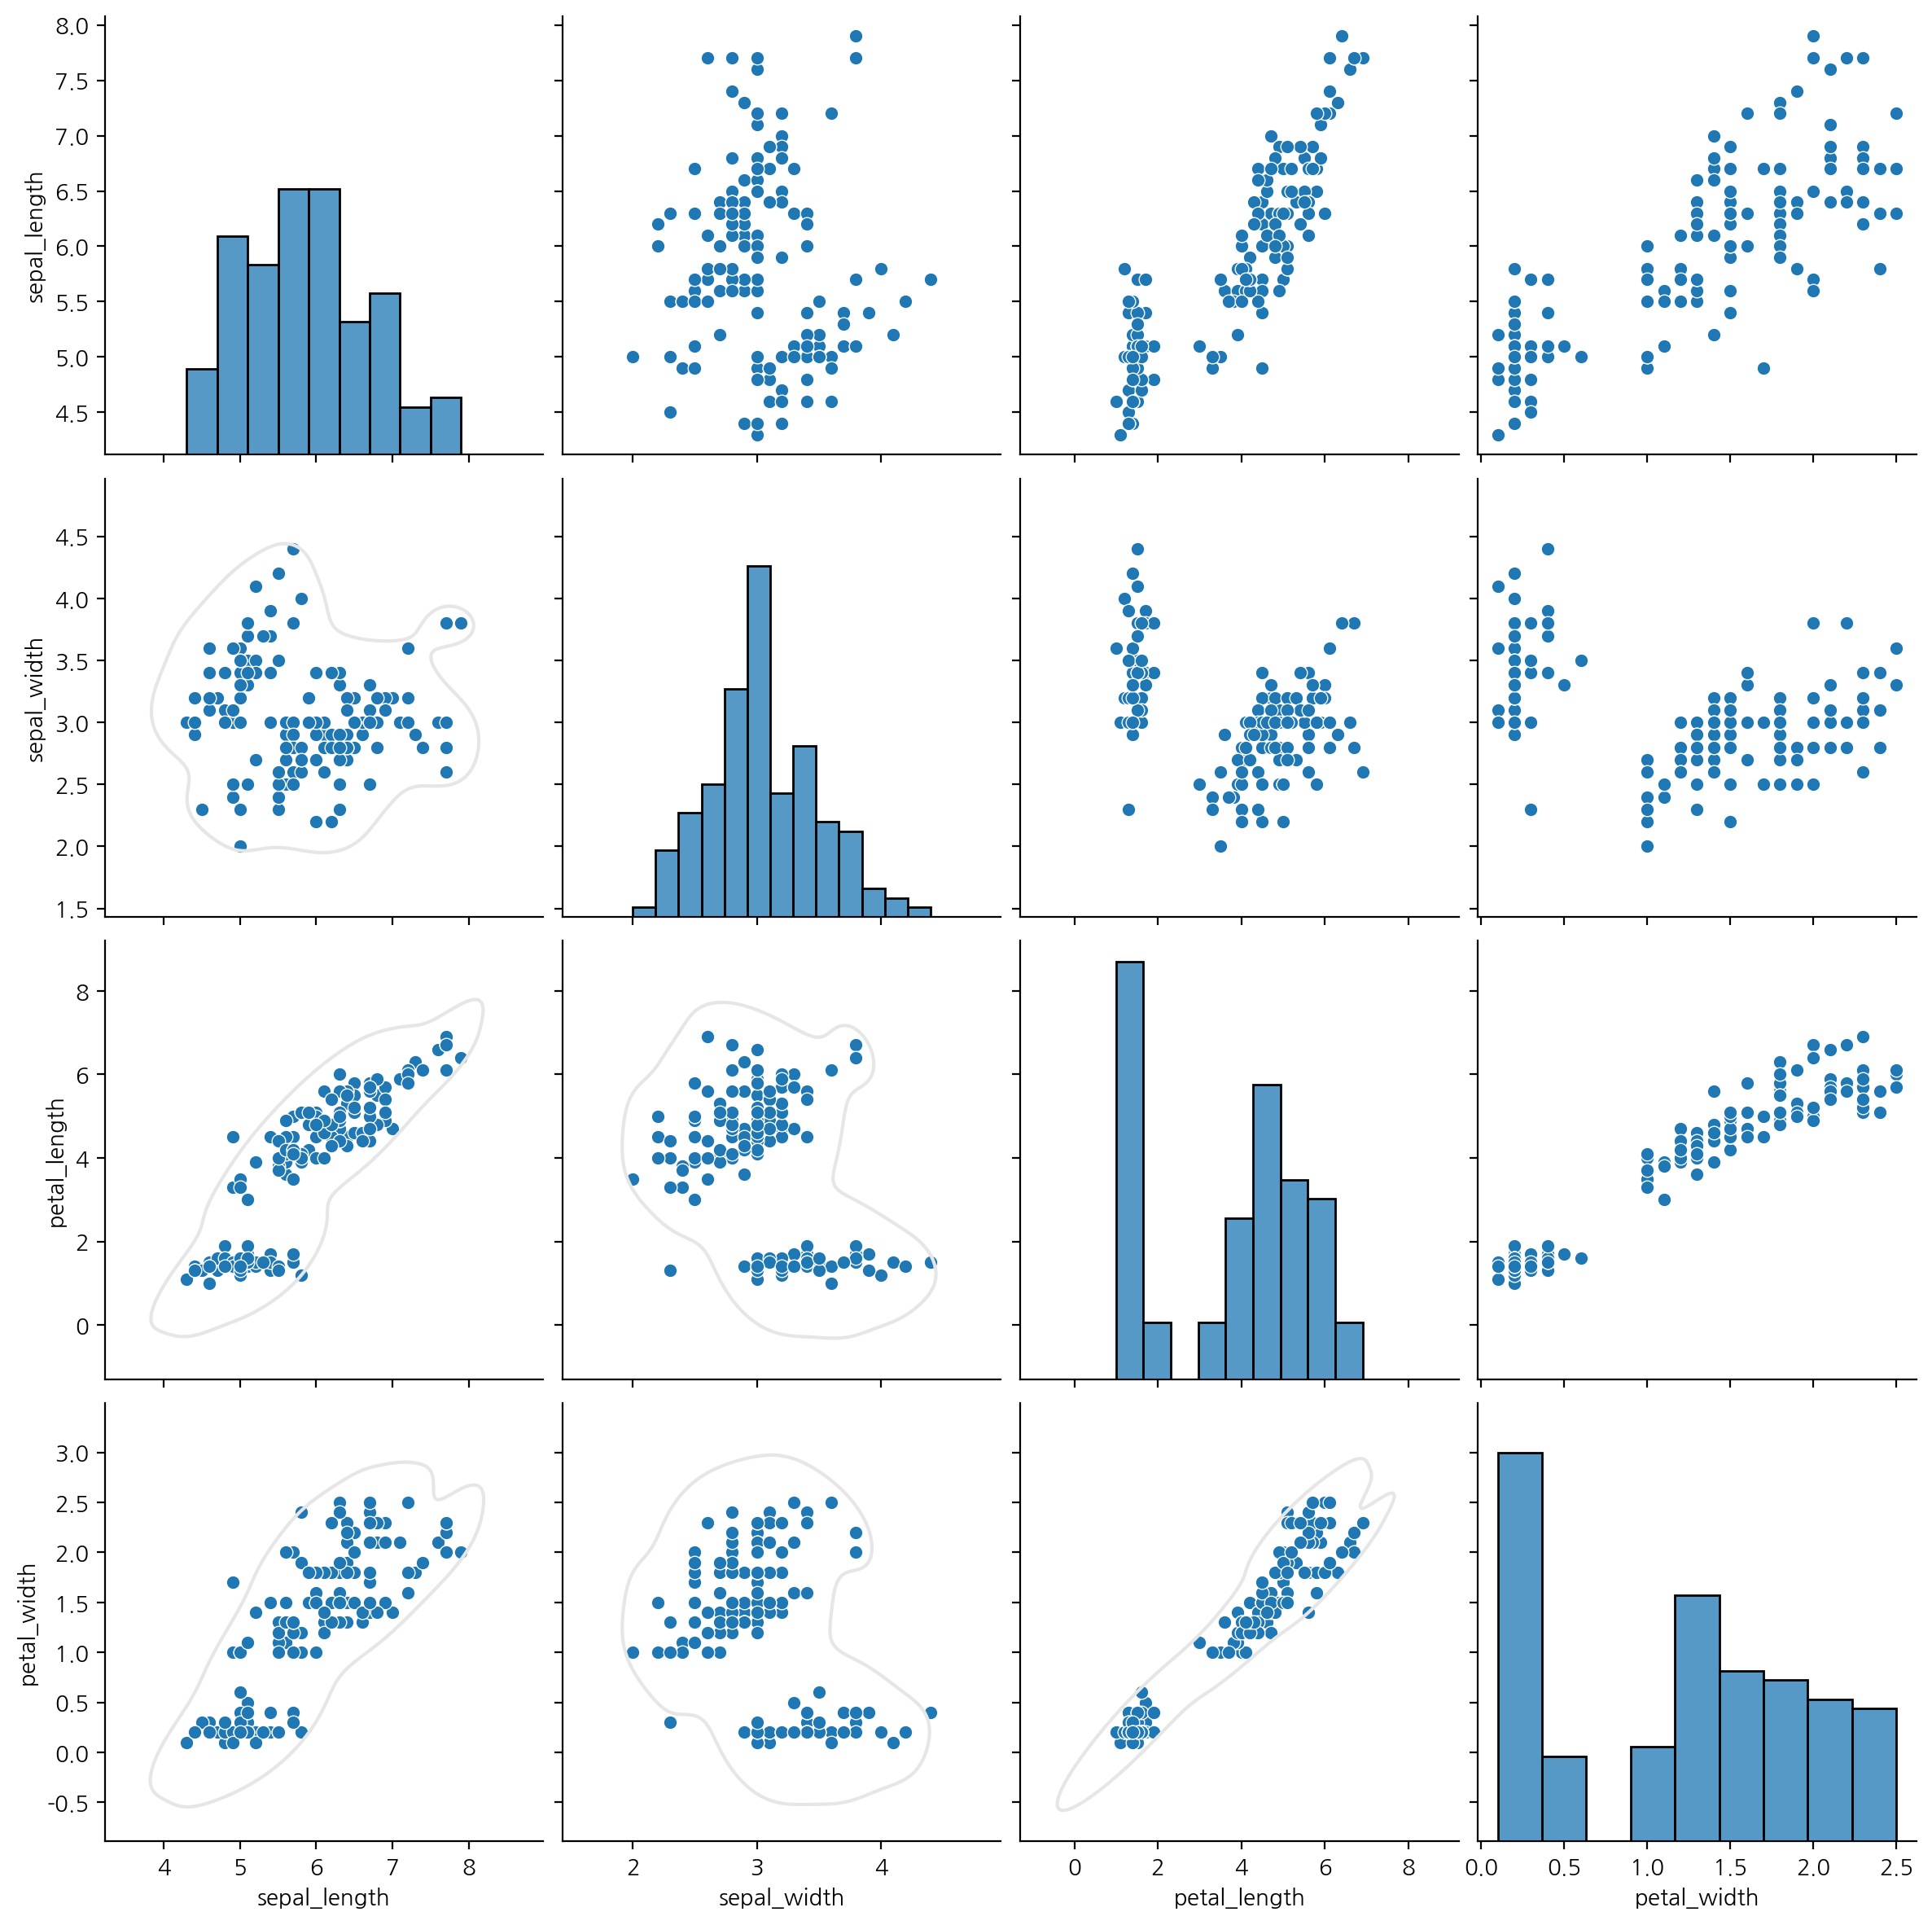

In [78]:
g = sns.pairplot(iris, height=3);
g.map_lower(sns.kdeplot, levels=2, color=".9");